# 11 — Survival Analysis

## Clinical Objective

This notebook extends the ICU mortality classification project into a **time-to-event analysis**.

The primary survival endpoint is:

- **Time origin:** ICU admission (`intime`)
- **Event:** in-hospital death
- **Event time:** `deathtime`
- **Censoring:** hospital discharge alive (`dischtime`)

The analysis includes:

- survival endpoint construction;
- endpoint validation;
- Kaplan–Meier survival estimation;
- subgroup survival curves;
- log-rank testing;
- Cox proportional hazards regression;
- hazard ratios and 95% confidence intervals;
- proportional-hazards diagnostics;
- reproducible output tables and figures.

Reusable survival-analysis logic is imported from `src.survival`.

> **Important:** The current analysis uses the MIMIC-IV demo cohort. Results are exploratory and are not intended for clinical use.

## 1. Locate the project root

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_DIR = cwd
elif (cwd.parent / "src").exists():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing src/. "
        "Open this notebook from the clinical-outcome-prediction project."
    )

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_DIR),
    )

print("Project root:", PROJECT_DIR)
print("Python executable:", sys.executable)

Project root: C:\Projects\clinical-outcome-prediction
Python executable: c:\Projects\clinical-outcome-prediction\.venv\Scripts\python.exe


## 2. Imports

The notebook uses project functions from `src.survival`.

If `lifelines` is not installed, run from the project root:

```powershell
.\.venv\Scripts\python.exe -m pip install lifelines
```

and add `lifelines` to `requirements.txt`.

In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.survival import (
    build_survival_dataset,
    validate_survival_dataset,
    summarize_survival_cohort,
    create_age_groups,
    fit_kaplan_meier,
    survival_probabilities_at_times,
    summarize_survival_by_group,
    plot_kaplan_meier,
    plot_kaplan_meier_by_group,
    run_logrank_test,
    choose_parsimonious_covariates,
    prepare_cox_dataset,
    fit_cox_model,
    extract_hazard_ratios,
    plot_hazard_ratios,
    check_proportional_hazards,
)

pd.set_option(
    "display.max_columns",
    None,
)

pd.set_option(
    "display.max_rows",
    200,
)

## 3. Define input and output directories

In [3]:
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"

RESULTS_DIR = PROJECT_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
ANALYSIS_DIR = RESULTS_DIR / "analysis"

for directory in [
    TABLES_DIR,
    FIGURES_DIR,
    ANALYSIS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Raw data:", RAW_DIR)
print("Results:", RESULTS_DIR)

Raw data: C:\Projects\clinical-outcome-prediction\data\raw
Results: C:\Projects\clinical-outcome-prediction\results


## 4. Locate MIMIC-IV source tables

The notebook searches recursively under `data/raw/` for:

- `admissions.csv.gz`
- `patients.csv.gz`
- `icustays.csv.gz`

This avoids hard-coding the exact demo directory name.

In [4]:
def find_single_file(
    root: Path,
    filename: str,
) -> Path:
    matches = list(
        root.rglob(
            filename
        )
    )

    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename!r} under {root}"
        )

    demo_matches = [
        path
        for path in matches
        if "demo" in str(path).lower()
    ]

    selected = (
        demo_matches[0]
        if demo_matches
        else matches[0]
    )

    if len(matches) > 1:
        print(
            f"Found {len(matches)} copies of {filename}; "
            f"using {selected}"
        )

    return selected


ADMISSIONS_PATH = find_single_file(
    RAW_DIR,
    "admissions.csv.gz",
)

PATIENTS_PATH = find_single_file(
    RAW_DIR,
    "patients.csv.gz",
)

ICUSTAYS_PATH = find_single_file(
    RAW_DIR,
    "icustays.csv.gz",
)

print("Admissions:", ADMISSIONS_PATH)
print("Patients:", PATIENTS_PATH)
print("ICU stays:", ICUSTAYS_PATH)

Admissions: C:\Projects\clinical-outcome-prediction\data\raw\mimic-iv-clinical-database-demo-2.2\hosp\admissions.csv.gz
Patients: C:\Projects\clinical-outcome-prediction\data\raw\mimic-iv-clinical-database-demo-2.2\hosp\patients.csv.gz
ICU stays: C:\Projects\clinical-outcome-prediction\data\raw\mimic-iv-clinical-database-demo-2.2\icu\icustays.csv.gz


## 5. Load MIMIC-IV tables

In [5]:
admissions_columns = [
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "deathtime",
    "admission_type",
    "admission_location",
    "insurance",
    "race",
    "hospital_expire_flag",
]

patients_columns = [
    "subject_id",
    "gender",
    "anchor_age",
]

icustays_columns = [
    "subject_id",
    "hadm_id",
    "stay_id",
    "first_careunit",
    "last_careunit",
    "intime",
    "outtime",
]

admissions = pd.read_csv(
    ADMISSIONS_PATH,
    usecols=lambda column:
        column in admissions_columns,
)

patients = pd.read_csv(
    PATIENTS_PATH,
    usecols=lambda column:
        column in patients_columns,
)

icustays = pd.read_csv(
    ICUSTAYS_PATH,
    usecols=lambda column:
        column in icustays_columns,
)

print(
    "Admissions shape:",
    admissions.shape,
)

print(
    "Patients shape:",
    patients.shape,
)

print(
    "ICU stays shape:",
    icustays.shape,
)

Admissions shape: (275, 10)
Patients shape: (100, 3)
ICU stays shape: (140, 7)


## 6. Convert timestamp columns

In [6]:
for column in [
    "admittime",
    "dischtime",
    "deathtime",
]:
    if column in admissions.columns:
        admissions[column] = pd.to_datetime(
            admissions[column],
            errors="coerce",
        )

for column in [
    "intime",
    "outtime",
]:
    if column in icustays.columns:
        icustays[column] = pd.to_datetime(
            icustays[column],
            errors="coerce",
        )

display(
    admissions[
        [
            "admittime",
            "dischtime",
            "deathtime",
        ]
    ].head()
)

display(
    icustays[
        [
            "intime",
            "outtime",
        ]
    ].head()
)

,admittime,dischtime,deathtime
0,2196-02-24 14:38:00,2196-03-04 14:02:00,NaT
1,2153-09-17 17:08:00,2153-09-25 13:20:00,NaT
2,2134-08-18 02:02:00,2134-08-23 19:35:00,NaT
3,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00
4,2113-08-04 18:46:00,2113-08-06 20:57:00,NaT


,intime,outtime
0,2154-04-24 23:03:44,2154-05-02 15:55:21
1,2169-01-15 04:56:00,2169-01-20 15:47:50
2,2170-02-24 18:18:46,2170-02-25 15:15:26
3,2176-11-26 02:34:49,2176-11-29 20:58:54
4,2150-06-03 20:12:32,2150-06-04 21:05:58


## 7. Build the first-ICU-stay adult cohort

To remain consistent with the prediction project:

- one row represents one ICU stay;
- only the first ICU stay for each hospital admission is retained;
- adults are retained;
- `stay_id` must be unique.

In [7]:
first_icu_stay = (
    icustays
    .sort_values(
        [
            "hadm_id",
            "intime",
        ]
    )
    .drop_duplicates(
        subset="hadm_id",
        keep="first",
    )
    .copy()
)

assert first_icu_stay[
    "hadm_id"
].is_unique

assert first_icu_stay[
    "stay_id"
].is_unique

cohort = (
    first_icu_stay
    .merge(
        admissions,
        on=[
            "subject_id",
            "hadm_id",
        ],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        patients,
        on="subject_id",
        how="left",
        validate="many_to_one",
    )
)

cohort = (
    cohort.loc[
        cohort[
            "anchor_age"
        ] >= 18
    ]
    .copy()
)

assert cohort[
    "stay_id"
].is_unique

assert cohort[
    "hospital_expire_flag"
].isin(
    [0, 1]
).all()

print(
    "Adult first-ICU cohort:",
    cohort.shape,
)

print(
    "Unique patients:",
    cohort[
        "subject_id"
    ].nunique(),
)

print(
    "Deaths:",
    int(
        cohort[
            "hospital_expire_flag"
        ].sum()
    ),
)

display(
    cohort.head()
)

Adult first-ICU cohort: (128, 17)
Unique patients: 100
Deaths: 15


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,admittime,dischtime,deathtime,admission_type,admission_location,insurance,race,hospital_expire_flag,gender,anchor_age
0,10023771,20044587,33177122,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2113-08-25 09:32:41,2113-08-27 16:27:53,2113-08-25 07:15:00,2113-08-30 14:15:00,NaT,ELECTIVE,PHYSICIAN REFERRAL,Medicare,WHITE,0,M,70
1,10005909,20199380,36496303,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2144-10-29 23:09:03,2144-11-02 15:24:29,2144-10-28 23:20:00,2144-11-02 15:23:00,NaT,OBSERVATION ADMIT,EMERGENCY ROOM,Other,WHITE,0,F,40
2,10003400,20214994,32128372,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2137-02-25 23:37:19,2137-03-10 21:29:36,2137-02-24 10:00:00,2137-03-19 15:45:00,NaT,URGENT,TRANSFER FROM SKILLED NURSING FACILITY,Medicare,BLACK/AFRICAN AMERICAN,0,F,72
3,10008454,20291550,31959184,Trauma SICU (TSICU),Trauma SICU (TSICU),2110-11-30 17:11:36,2110-12-05 16:48:24,2110-11-30 06:31:00,2110-12-10 15:53:00,NaT,EW EMER.,EMERGENCY ROOM,Other,WHITE,0,F,26
4,10019385,20297618,39268883,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2180-02-21 08:34:06,2180-02-22 16:05:14,2180-02-15 20:28:00,2180-02-25 13:45:00,NaT,URGENT,TRANSFER FROM HOSPITAL,Other,WHITE,0,M,44


## 8. Merge existing first-24-hour clinical features when available

The prediction workflow already created first-24-hour clinical variables.

This notebook attempts to load the existing train/validation/test splits from `src.data`, combines them, and merges useful baseline covariates onto the survival cohort by `stay_id`.

If those split files are unavailable, the survival analysis still runs using demographics and admission data.

In [8]:
modeling_features = None

try:
    from src.data import (
        load_modeling_splits,
    )

    (
        train_df,
        validation_df,
        test_df,
    ) = load_modeling_splits()

    modeling_features = (
        pd.concat(
            [
                train_df,
                validation_df,
                test_df,
            ],
            ignore_index=True,
        )
        .drop_duplicates(
            subset="stay_id",
            keep="first",
        )
    )

    print(
        "Loaded existing modeling features:",
        modeling_features.shape,
    )

except Exception as exc:
    print(
        "Existing modeling features were not merged."
    )

    print(
        "Reason:",
        repr(exc),
    )

Loaded existing modeling features: (128, 73)


In [9]:
candidate_clinical_features = [
    "creatinine_first",
    "creatinine_min",
    "creatinine_max",
    "bun_first",
    "bun_min",
    "bun_max",
    "lactate_first",
    "lactate_max",
    "bicarbonate_first",
    "potassium_first",
    "wbc_first",
    "platelets_first",
    "heart_rate_mean",
    "map_mean",
    "map_min",
    "respiratory_rate_mean",
    "temperature_c_mean",
    "oxygen_saturation_mean",
]

if modeling_features is not None:
    available_modeling_features = [
        column
        for column
        in candidate_clinical_features
        if (
            column
            in modeling_features.columns
        )
        and (
            column
            not in cohort.columns
        )
    ]

    if available_modeling_features:
        cohort = cohort.merge(
            modeling_features[
                [
                    "stay_id"
                ]
                + available_modeling_features
            ],
            on="stay_id",
            how="left",
            validate="one_to_one",
        )

        print(
            "Merged clinical covariates:",
            available_modeling_features,
        )
    else:
        print(
            "No additional candidate clinical features were available."
        )

Merged clinical covariates: ['creatinine_first', 'creatinine_min', 'creatinine_max', 'bun_first', 'bun_min', 'bun_max', 'lactate_first', 'lactate_max', 'bicarbonate_first', 'potassium_first', 'wbc_first', 'platelets_first', 'heart_rate_mean', 'map_mean', 'map_min', 'respiratory_rate_mean', 'temperature_c_mean']


## 9. Build the survival dataset using `src.survival`

The reusable function:

```python
build_survival_dataset(cohort)
```

adds the survival-analysis variables:

- `event`
- `death_time_missing`
- `end_time_source`
- `end_time`
- `duration_days`

Conceptually:

```text
hospital_expire_flag → event

death/discharge time → end_time

end_time - ICU admission → duration_days
```

In [10]:
survival_df = (
    build_survival_dataset(
        cohort,
        start_col="intime",
        death_time_col="deathtime",
        discharge_time_col="dischtime",
        source_event_col=(
            "hospital_expire_flag"
        ),
        stay_id_col="stay_id",
        allow_death_time_fallback=True,
    )
)

display(
    survival_df[
        [
            "subject_id",
            "hadm_id",
            "stay_id",
            "intime",
            "end_time",
            "end_time_source",
            "duration_days",
            "event",
        ]
    ].head(10)
)

,subject_id,hadm_id,stay_id,intime,end_time,end_time_source,duration_days,event
0,10023771,20044587,33177122,2113-08-25 09:32:41,2113-08-30 14:15:00,dischtime_alive,5.196053,0
1,10005909,20199380,36496303,2144-10-29 23:09:03,2144-11-02 15:23:00,dischtime_alive,3.676354,0
2,10003400,20214994,32128372,2137-02-25 23:37:19,2137-03-19 15:45:00,dischtime_alive,21.672002,0
3,10008454,20291550,31959184,2110-11-30 17:11:36,2110-12-10 15:53:00,dischtime_alive,9.945417,0
4,10019385,20297618,39268883,2180-02-21 08:34:06,2180-02-25 13:45:00,dischtime_alive,4.215903,0
5,10002428,20321825,34807493,2156-04-30 21:53:00,2156-05-03 16:36:00,dischtime_alive,2.779861,0
6,10007928,20338077,35128235,2129-04-06 00:25:00,2129-04-11 17:25:00,dischtime_alive,5.708333,0
7,10005866,20364112,34170353,2149-10-02 12:48:08,2149-10-25 18:50:00,dischtime_alive,23.251296,0
8,10032725,20611640,30101877,2143-03-22 06:42:00,2143-03-25 13:00:00,dischtime_alive,3.262500,0
9,10005817,20626031,32604416,2132-12-15 09:29:01,2132-12-20 15:04:00,dischtime_alive,5.232627,0


## 10. Audit survival endpoint quality

In [11]:
endpoint_quality = pd.Series(
    {
        "rows_before_validation":
            len(
                survival_df
            ),
        "events":
            int(
                survival_df[
                    "event"
                ]
                .fillna(0)
                .sum()
            ),
        "censored_alive":
            int(
                (
                    survival_df[
                        "event"
                    ] == 0
                ).sum()
            ),
        "missing_intime":
            int(
                survival_df[
                    "intime"
                ]
                .isna()
                .sum()
            ),
        "missing_end_time":
            int(
                survival_df[
                    "end_time"
                ]
                .isna()
                .sum()
            ),
        "nonpositive_duration":
            int(
                (
                    survival_df[
                        "duration_days"
                    ] <= 0
                )
                .fillna(False)
                .sum()
            ),
        "death_time_fallback_count":
            int(
                survival_df[
                    "death_time_missing"
                ]
                .fillna(False)
                .sum()
            ),
    },
    name="value",
).to_frame()

display(
    endpoint_quality
)

,value
rows_before_validation,128
events,15
censored_alive,113
missing_intime,0
missing_end_time,0
nonpositive_duration,0
death_time_fallback_count,0


## 11. Validate the survival dataset

Invalid duration/event rows are explicitly removed.

Duplicate ICU stay IDs still trigger an error.

In [12]:
survival_analysis_df = (
    validate_survival_dataset(
        survival_df,
        stay_id_col="stay_id",
        duration_col="duration_days",
        event_col="event",
        drop_invalid=True,
    )
)

print(
    "Validated survival rows:",
    len(
        survival_analysis_df
    ),
)

print(
    "Deaths:",
    int(
        survival_analysis_df[
            "event"
        ].sum()
    ),
)

print(
    "Censored:",
    int(
        (
            survival_analysis_df[
                "event"
            ] == 0
        ).sum()
    ),
)

assert (
    survival_analysis_df[
        "duration_days"
    ] > 0
).all()

assert (
    survival_analysis_df[
        "event"
    ]
    .isin(
        [0, 1]
    )
    .all()
)

assert survival_analysis_df[
    "stay_id"
].is_unique

Validated survival rows: 128
Deaths: 15
Censored: 113


## 12. Summarize the survival cohort

In [13]:
survival_cohort_summary = (
    summarize_survival_cohort(
        survival_analysis_df,
        subject_id_col="subject_id",
        duration_col="duration_days",
        event_col="event",
    )
)

display(
    survival_cohort_summary
)

,metric,value
0,ICU stays,128.000000
1,Unique patients,100.000000
2,Deaths,15.000000
3,Discharged alive / censored,113.000000
4,Event rate,0.117188
5,Median observed duration (days),5.719838
6,Minimum duration (days),0.481030
7,Maximum duration (days),44.927130


## 13. Inspect observed survival duration

count    128.000000
mean       8.239453
std        6.865968
min        0.481030
25%        4.148073
50%        5.719838
75%       10.027297
max       44.927130
Name: duration_days, dtype: float64

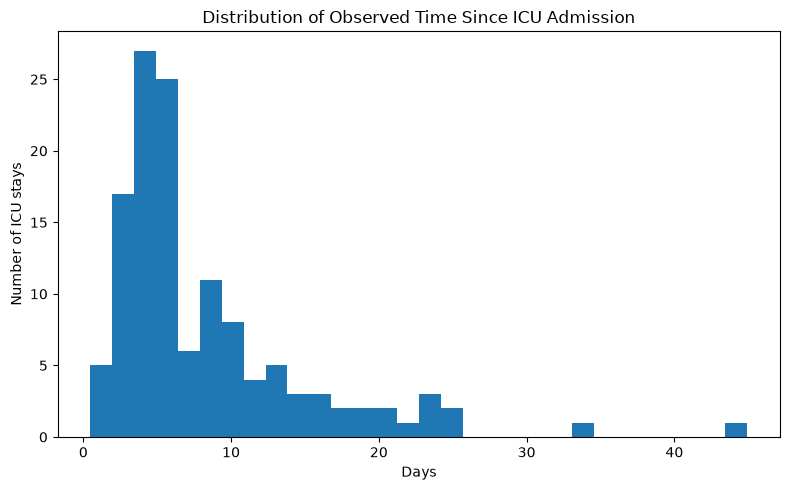

In [14]:
display(
    survival_analysis_df[
        "duration_days"
    ].describe()
)

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.hist(
    survival_analysis_df[
        "duration_days"
    ],
    bins=30,
)

ax.set_title(
    "Distribution of Observed Time Since ICU Admission"
)

ax.set_xlabel(
    "Days"
)

ax.set_ylabel(
    "Number of ICU stays"
)

plt.tight_layout()

DURATION_FIGURE = (
    FIGURES_DIR
    / "survival_duration_distribution.png"
)

plt.savefig(
    DURATION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 14. Fit the overall Kaplan–Meier estimator

`fit_kaplan_meier()` uses:

- `duration_days` as observed time;
- `event` as the death/censoring indicator.

The fitted object is stored in `kmf`.

In [15]:
kmf = fit_kaplan_meier(
    survival_analysis_df,
    duration_col="duration_days",
    event_col="event",
    label="Overall cohort",
)

print(
    "Kaplan–Meier model fitted."
)

Kaplan–Meier model fitted.


## 15. Plot the overall Kaplan–Meier survival curve

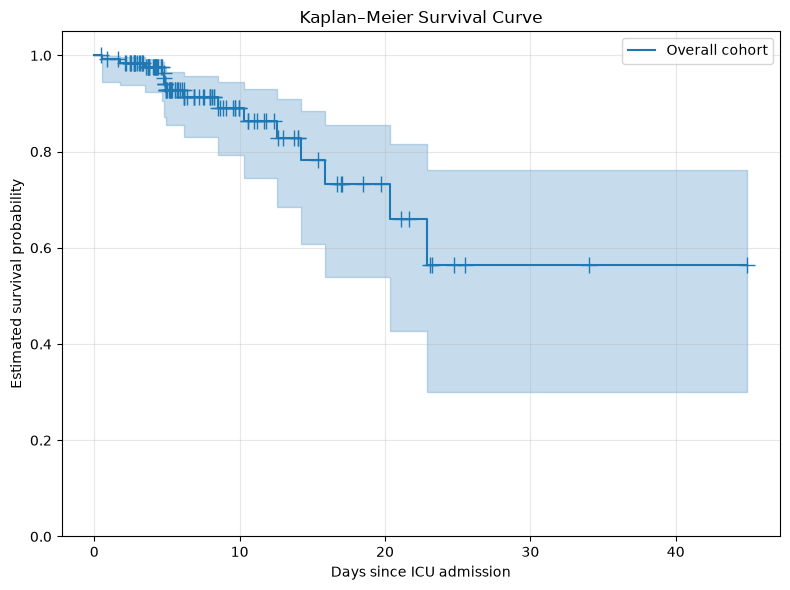

In [16]:
KM_OVERALL_FIGURE = (
    FIGURES_DIR
    / "km_overall.png"
)

fig, ax = plot_kaplan_meier(
    kmf,
    title=(
        "Kaplan–Meier Survival Curve"
    ),
    xlabel=(
        "Days since ICU admission"
    ),
    ylabel=(
        "Estimated survival probability"
    ),
    show_censors=True,
    ci_show=True,
    save_path=KM_OVERALL_FIGURE,
)

plt.show()

## 16. Estimate survival probabilities at selected time points

In [17]:
survival_probability_table = (
    survival_probabilities_at_times(
        kmf,
        times=[
            1,
            3,
            7,
            14,
            30,
        ],
        time_column_name="day",
    )
)

display(
    survival_probability_table
)

median_survival = (
    kmf.median_survival_time_
)

if np.isfinite(
    median_survival
):
    print(
        "Estimated median survival:",
        median_survival,
        "days",
    )
else:
    print(
        "Median survival was not reached during observed follow-up."
    )

,day,estimated_survival_probability
0,1,0.992126
1,3,0.984125
2,7,0.913172
3,14,0.827590
4,30,0.565274


Median survival was not reached during observed follow-up.


## 17. Create age groups

In [18]:
survival_analysis_df = (
    create_age_groups(
        survival_analysis_df,
        age_col="anchor_age",
        output_col="age_group",
    )
)

age_group_summary = (
    summarize_survival_by_group(
        survival_analysis_df,
        group_col="age_group",
        duration_col="duration_days",
        event_col="event",
        id_col="stay_id",
    )
)

display(
    age_group_summary
)

,age_group,patients,deaths,event_rate,median_duration_days
0,18-49,28,0,0.000000,5.020162
1,50-69,62,10,0.161290,5.169010
2,70+,38,5,0.131579,7.521939


## 18. Kaplan–Meier survival by age group

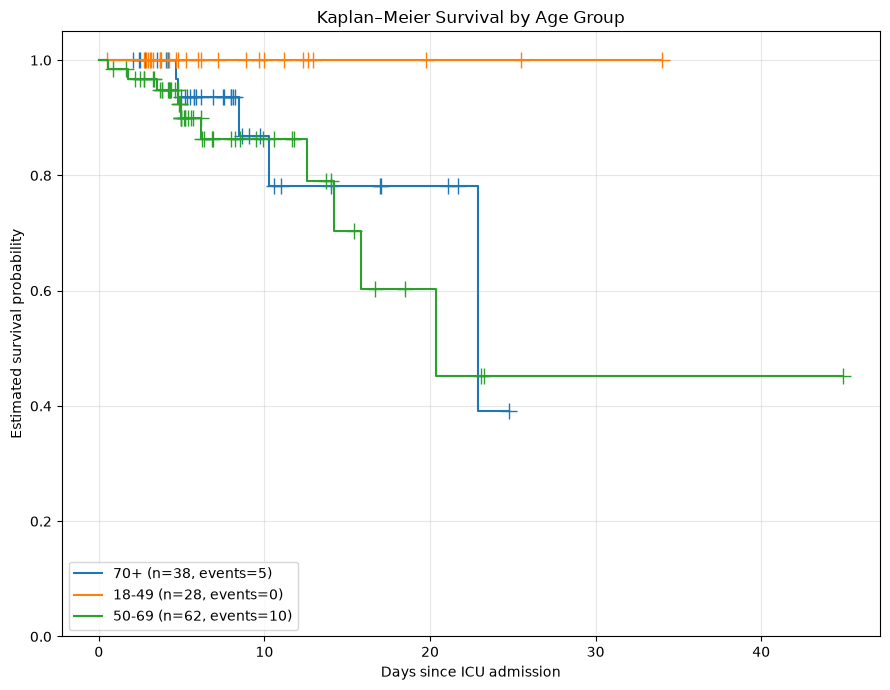

In [19]:
KM_AGE_FIGURE = (
    FIGURES_DIR
    / "km_by_age_group.png"
)

fig, ax = (
    plot_kaplan_meier_by_group(
        survival_analysis_df,
        group_col="age_group",
        duration_col="duration_days",
        event_col="event",
        title=(
            "Kaplan–Meier Survival by Age Group"
        ),
        ci_show=False,
        show_censors=True,
        save_path=KM_AGE_FIGURE,
    )
)

plt.show()

## 19. Kaplan–Meier survival by sex

In [20]:
gender_summary = (
    summarize_survival_by_group(
        survival_analysis_df,
        group_col="gender",
        duration_col="duration_days",
        event_col="event",
        id_col="stay_id",
    )
)

display(
    gender_summary
)

,gender,patients,deaths,event_rate,median_duration_days
0,F,59,3,0.050847,5.520625
1,M,69,12,0.173913,6.142488


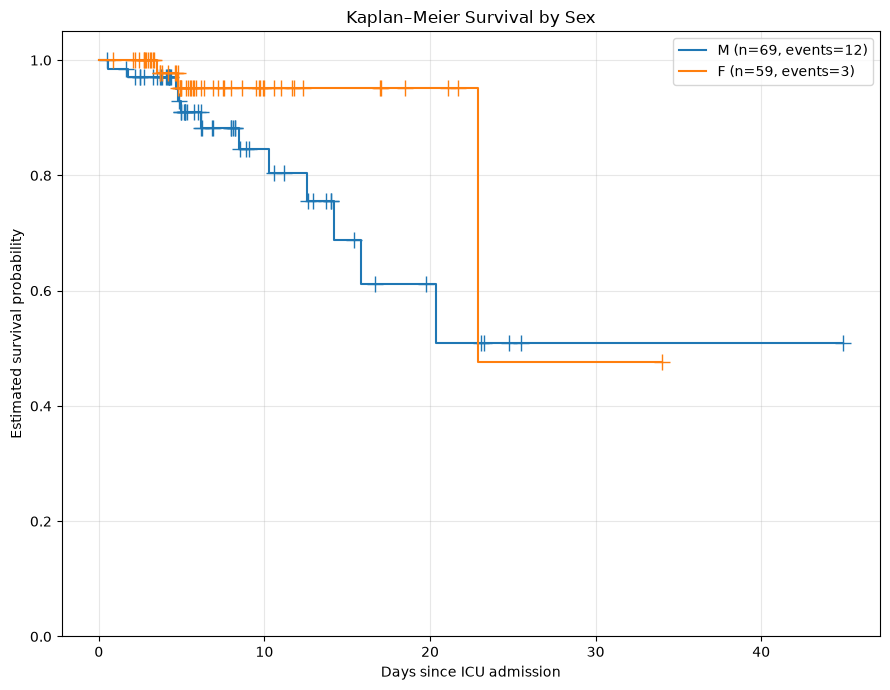

In [21]:
KM_GENDER_FIGURE = (
    FIGURES_DIR
    / "km_by_gender.png"
)

fig, ax = (
    plot_kaplan_meier_by_group(
        survival_analysis_df,
        group_col="gender",
        duration_col="duration_days",
        event_col="event",
        title=(
            "Kaplan–Meier Survival by Sex"
        ),
        ci_show=False,
        show_censors=True,
        save_path=KM_GENDER_FIGURE,
    )
)

plt.show()

## 20. Log-rank test: female vs male

The log-rank test evaluates whether the two groups have different survival distributions.

Because the demo cohort is small, this is an **exploratory comparison**, not confirmatory inference.

In [22]:
logrank_summary = (
    run_logrank_test(
        survival_analysis_df,
        group_col="gender",
        group_a="F",
        group_b="M",
        duration_col="duration_days",
        event_col="event",
    )
)

display(
    logrank_summary
)

,comparison,n_group_a,events_group_a,n_group_b,events_group_b,test_statistic,p_value
0,F vs M,59,3,69,12,2.778559,0.095534


## 21. Define candidate Cox covariates

The demo cohort contains few mortality events, so the Cox model must remain parsimonious.

The candidate list is a **clinical/analysis decision** and therefore stays visible in the notebook.

The reusable function in `src.survival` determines how many available covariates can reasonably be retained for this exploratory analysis.

In [23]:
cox_source = (
    survival_analysis_df
    .copy()
)

cox_source[
    "gender_male"
] = np.where(
    cox_source[
        "gender"
    ] == "M",
    1.0,
    np.where(
        cox_source[
            "gender"
        ] == "F",
        0.0,
        np.nan,
    ),
)

candidate_cox_covariates = [
    "anchor_age",
    "creatinine_first",
    "bun_first",
    "lactate_first",
    "bicarbonate_first",
    "potassium_first",
    "gender_male",
]

selected_cox_covariates = (
    choose_parsimonious_covariates(
        cox_source,
        candidate_cox_covariates,
        event_col="event",
        events_per_covariate=5,
        minimum_covariates=1,
    )
)

print(
    "Observed deaths:",
    int(
        cox_source[
            "event"
        ].sum()
    ),
)

print(
    "Candidate covariates:",
    candidate_cox_covariates,
)

print(
    "Selected Cox covariates:",
    selected_cox_covariates,
)

if not selected_cox_covariates:
    raise ValueError(
        "No usable Cox covariates were available."
    )

Observed deaths: 15
Candidate covariates: ['anchor_age', 'creatinine_first', 'bun_first', 'lactate_first', 'bicarbonate_first', 'potassium_first', 'gender_male']
Selected Cox covariates: ['anchor_age', 'creatinine_first', 'bun_first']


## 22. Prepare the Cox dataset

The reusable preprocessing function:

- validates duration and event values;
- converts covariates to numeric;
- median-imputes missing numeric values;
- removes zero-variance covariates.

In [24]:
(
    cox_df,
    retained_cox_covariates,
) = prepare_cox_dataset(
    cox_source,
    selected_cox_covariates,
    duration_col="duration_days",
    event_col="event",
    median_impute=True,
    drop_zero_variance=True,
)

print(
    "Retained Cox covariates:",
    retained_cox_covariates,
)

display(
    cox_df.describe().T
)

Retained Cox covariates: ['anchor_age', 'creatinine_first', 'bun_first']


,count,mean,std,min,25%,50%,75%,max
duration_days,128.0,8.239453,6.865968,0.48103,4.148073,5.719838,10.027297,44.92713
event,128.0,0.117188,0.322907,0.00000,0.000000,0.000000,0.000000,1.00000
anchor_age,128.0,61.710938,15.691490,21.00000,52.000000,63.000000,72.000000,91.00000
creatinine_first,128.0,1.511719,1.918194,0.20000,0.600000,0.900000,1.425000,15.20000
bun_first,128.0,25.812500,22.153633,7.00000,13.000000,17.000000,30.250000,154.00000


## 23. Fit the Cox proportional hazards model

The function first attempts an unpenalized Cox model.

If the tiny demo dataset produces a convergence failure, the function retries with a small penalizer (`0.1`) and reports that fallback in metadata.

In [25]:
(
    cph,
    cox_fit_metadata,
) = fit_cox_model(
    cox_df,
    duration_col="duration_days",
    event_col="event",
    penalizer_fallback=0.1,
)

cph.print_summary()

display(
    pd.Series(
        cox_fit_metadata
    ).to_frame(
        name="value"
    )
)

<lifelines.CoxPHFitter: fitted with 128 total observations, 113 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 128
number of events observed = 15
   partial log-likelihood = -53.25
         time fit was run = 2026-08-08 00:22:18 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
anchor_age        0.03      1.03      0.02           -0.01            0.07                0.99                1.08
creatinine_first -0.01      0.99      0.20           -0.41            0.38                0.67                1.46
bun_first         0.01      1.01      0.01           -0.01            0.03                0.99                1.03

                  cmp to     z    p  -log2(p)
covariate                                    
anchor_age          0.00  1.68 0.09      3.42
creatinine_first    0.00 -0.07 0.94      0.09
bun_first           0.00  1.34 0.18      2.48
---
Concordance = 0.61
Partial AIC = 112.50
log-likelihood ratio test = 6.29 on 3 df
-log2(p) of ll-ratio test = 3.34

,value
penalizer_fallback_used,False
unpenalized_error,None
n_rows,128
n_events,15


## 24. Extract hazard ratios

For the Cox model:

- `HR > 1` → higher estimated instantaneous hazard;
- `HR < 1` → lower estimated instantaneous hazard;
- `HR = 1` → no estimated difference.

Hazard ratios are **conditional associations**, not causal effects.

In [26]:
cox_results = (
    extract_hazard_ratios(
        cph
    )
)

display(
    cox_results
)

,covariate,coef,hazard_ratio,hr_lower_95,hr_upper_95,p_value
0,anchor_age,0.034022,1.034607,0.994325,1.076521,0.093137
1,creatinine_first,-0.014905,0.985206,0.665978,1.457451,0.940533
2,bun_first,0.011702,1.011771,0.994660,1.029177,0.178715


## 25. Hazard-ratio forest plot

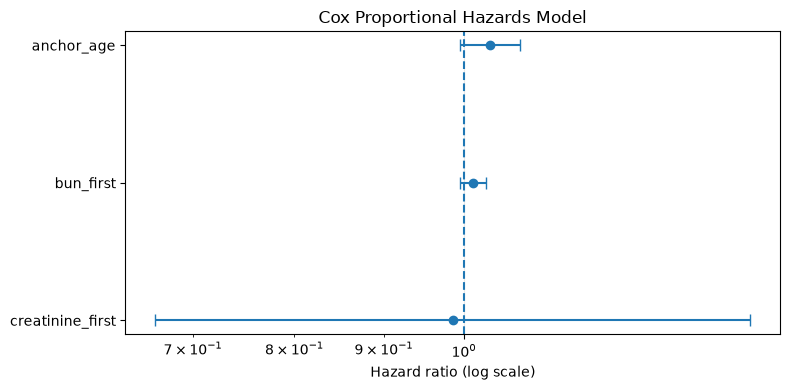

In [27]:
COX_FOREST_FIGURE = (
    FIGURES_DIR
    / "cox_hazard_ratio_forest_plot.png"
)

try:
    fig, ax = (
        plot_hazard_ratios(
            cox_results,
            title=(
                "Cox Proportional Hazards Model"
            ),
            save_path=(
                COX_FOREST_FIGURE
            ),
        )
    )

    plt.show()

except ValueError as exc:
    print(
        "Forest plot could not be created:",
        exc,
    )

## 26. Check the proportional-hazards assumption

The Cox PH model assumes that the relative hazard associated with a covariate remains approximately constant over time.

The diagnostic output is exploratory because the demo dataset is small.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


,value
status,completed_without_exception
error,None


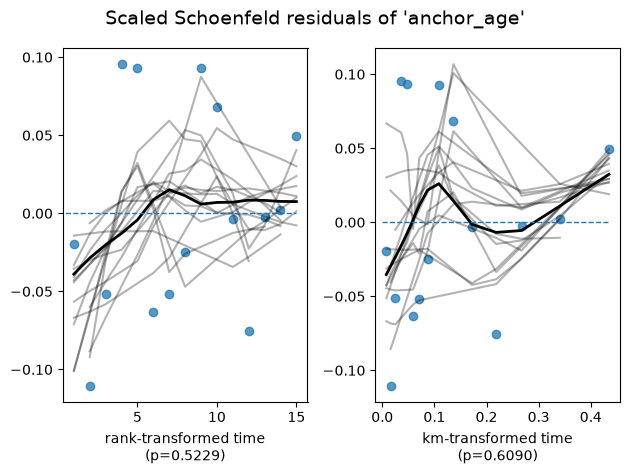

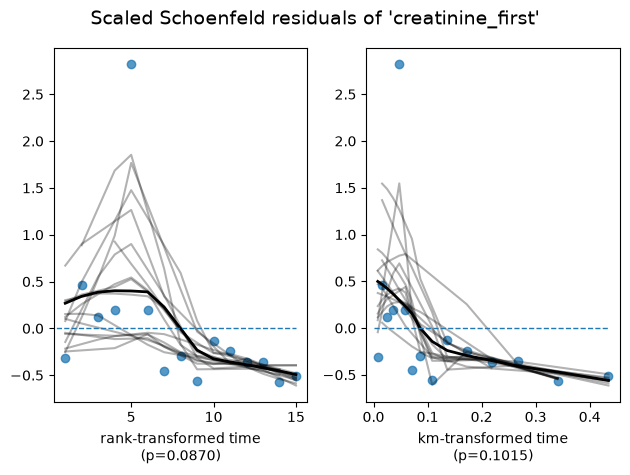

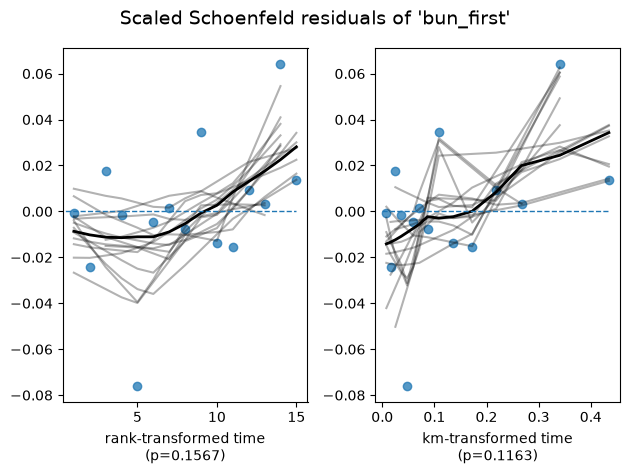

In [28]:
ph_results = (
    check_proportional_hazards(
        cph,
        cox_df,
        p_value_threshold=0.05,
        show_plots=True,
    )
)

display(
    pd.Series(
        ph_results
    ).to_frame(
        name="value"
    )
)

## 27. Review event counts by subgroup

A survival curve or subgroup comparison is difficult to interpret when a group contains very few patients or events.

In [29]:
subgroup_quality_tables = {}

for subgroup_column in [
    "age_group",
    "gender",
    "first_careunit",
    "admission_type",
]:
    if (
        subgroup_column
        not in survival_analysis_df.columns
    ):
        continue

    table = (
        summarize_survival_by_group(
            survival_analysis_df,
            group_col=subgroup_column,
            duration_col="duration_days",
            event_col="event",
            id_col="stay_id",
        )
    )

    subgroup_quality_tables[
        subgroup_column
    ] = table

    print(
        "\nSubgroup:",
        subgroup_column,
    )

    display(
        table
    )


Subgroup: age_group


,age_group,patients,deaths,event_rate,median_duration_days
0,18-49,28,0,0.000000,5.020162
1,50-69,62,10,0.161290,5.169010
2,70+,38,5,0.131579,7.521939



Subgroup: gender


,gender,patients,deaths,event_rate,median_duration_days
0,F,59,3,0.050847,5.520625
1,M,69,12,0.173913,6.142488



Subgroup: first_careunit


,first_careunit,patients,deaths,event_rate,median_duration_days
0,Cardiac Vascular Intensive Care Unit (CVICU),25,0,0.000000,5.196053
1,Coronary Care Unit (CCU),10,3,0.300000,7.426429
2,Medical Intensive Care Unit (MICU),25,5,0.200000,3.503183
3,Medical/Surgical Intensive Care Unit (MICU/SICU),22,3,0.136364,7.737517
4,Neuro Intermediate,1,0,0.000000,0.861968
5,Neuro Stepdown,1,0,0.000000,8.622407
6,Neuro Surgical Intensive Care Unit (Neuro SICU),2,1,0.500000,9.894803
7,Surgical Intensive Care Unit (SICU),27,2,0.074074,4.945810
8,Trauma SICU (TSICU),15,1,0.066667,8.479062



Subgroup: admission_type


,admission_type,patients,deaths,event_rate,median_duration_days
0,DIRECT EMER.,4,1,0.250000,15.756493
1,ELECTIVE,5,0,0.000000,4.876273
2,EW EMER.,62,6,0.096774,5.730903
3,OBSERVATION ADMIT,17,3,0.176471,9.048924
4,SURGICAL SAME DAY ADMISSION,15,0,0.000000,5.306123
5,URGENT,25,5,0.200000,5.232627


## 28. Save final survival-analysis outputs

In [30]:
SURVIVAL_COHORT_SUMMARY_PATH = (
    TABLES_DIR
    / "survival_cohort_summary.csv"
)

SURVIVAL_PROBABILITY_PATH = (
    TABLES_DIR
    / "km_survival_probabilities.csv"
)

AGE_GROUP_SUMMARY_PATH = (
    TABLES_DIR
    / "survival_age_group_summary.csv"
)

GENDER_SUMMARY_PATH = (
    TABLES_DIR
    / "survival_gender_summary.csv"
)

LOGRANK_PATH = (
    TABLES_DIR
    / "survival_logrank_gender.csv"
)

COX_RESULTS_PATH = (
    TABLES_DIR
    / "cox_hazard_ratios.csv"
)

SURVIVAL_ANALYSIS_DATA_PATH = (
    ANALYSIS_DIR
    / "survival_analysis_cohort.csv"
)

SURVIVAL_METADATA_PATH = (
    ANALYSIS_DIR
    / "survival_analysis_metadata.json"
)

survival_cohort_summary.to_csv(
    SURVIVAL_COHORT_SUMMARY_PATH,
    index=False,
)

survival_probability_table.to_csv(
    SURVIVAL_PROBABILITY_PATH,
    index=False,
)

age_group_summary.to_csv(
    AGE_GROUP_SUMMARY_PATH,
    index=False,
)

gender_summary.to_csv(
    GENDER_SUMMARY_PATH,
    index=False,
)

logrank_summary.to_csv(
    LOGRANK_PATH,
    index=False,
)

cox_results.to_csv(
    COX_RESULTS_PATH,
    index=False,
)

survival_analysis_df.to_csv(
    SURVIVAL_ANALYSIS_DATA_PATH,
    index=False,
)

for (
    subgroup_column,
    table,
) in subgroup_quality_tables.items():
    table.to_csv(
        TABLES_DIR
        / (
            "survival_subgroup_"
            f"{subgroup_column}.csv"
        ),
        index=False,
    )

metadata = {
    "analysis": (
        "Time-to-event analysis of "
        "in-hospital mortality"
    ),
    "time_origin": (
        "ICU admission (intime)"
    ),
    "event": (
        "In-hospital death"
    ),
    "event_indicator_source": (
        "hospital_expire_flag"
    ),
    "event_time": (
        "deathtime"
    ),
    "censoring": (
        "Hospital discharge alive "
        "(dischtime)"
    ),
    "rows_in_survival_analysis":
        int(
            len(
                survival_analysis_df
            )
        ),
    "events":
        int(
            survival_analysis_df[
                "event"
            ].sum()
        ),
    "event_rate":
        float(
            survival_analysis_df[
                "event"
            ].mean()
        ),
    "death_time_fallback_count":
        int(
            survival_analysis_df[
                "death_time_missing"
            ]
            .fillna(False)
            .sum()
        ),
    "candidate_cox_covariates":
        candidate_cox_covariates,
    "selected_cox_covariates":
        selected_cox_covariates,
    "retained_cox_covariates":
        retained_cox_covariates,
    "cox_fit_metadata":
        cox_fit_metadata,
    "ph_results":
        ph_results,
    "limitations": [
        "MIMIC-IV demo cohort is small.",
        "The number of mortality events is limited.",
        "Kaplan-Meier estimates may be unstable.",
        "Cox hazard-ratio estimates may be unstable.",
        "The Cox model is deliberately parsimonious.",
        "Discharge alive is treated as censoring.",
        "Discharge may behave as a competing event.",
        "No causal interpretation is intended.",
        "The analysis has not been externally validated.",
        "The analysis is not intended for clinical use.",
    ],
}

with open(
    SURVIVAL_METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
        default=str,
    )

print(
    "Final survival-analysis outputs saved."
)

Final survival-analysis outputs saved.


## 29. Validate expected output files

In [31]:
expected_outputs = [
    SURVIVAL_COHORT_SUMMARY_PATH,
    SURVIVAL_PROBABILITY_PATH,
    AGE_GROUP_SUMMARY_PATH,
    GENDER_SUMMARY_PATH,
    LOGRANK_PATH,
    COX_RESULTS_PATH,
    SURVIVAL_ANALYSIS_DATA_PATH,
    SURVIVAL_METADATA_PATH,
    DURATION_FIGURE,
    KM_OVERALL_FIGURE,
    KM_AGE_FIGURE,
    KM_GENDER_FIGURE,
]

if (
    "COX_FOREST_FIGURE"
    in globals()
    and COX_FOREST_FIGURE.exists()
):
    expected_outputs.append(
        COX_FOREST_FIGURE
    )

for path in expected_outputs:
    print(
        (
            "[OK]"
            if path.exists()
            else "[MISSING]"
        ),
        path,
    )

assert all(
    path.exists()
    for path in expected_outputs
)

print(
    "All expected Notebook 11 outputs were created."
)

[OK] C:\Projects\clinical-outcome-prediction\results\tables\survival_cohort_summary.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\km_survival_probabilities.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\survival_age_group_summary.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\survival_gender_summary.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\survival_logrank_gender.csv
[OK] C:\Projects\clinical-outcome-prediction\results\tables\cox_hazard_ratios.csv
[OK] C:\Projects\clinical-outcome-prediction\results\analysis\survival_analysis_cohort.csv
[OK] C:\Projects\clinical-outcome-prediction\results\analysis\survival_analysis_metadata.json
[OK] C:\Projects\clinical-outcome-prediction\results\figures\survival_duration_distribution.png
[OK] C:\Projects\clinical-outcome-prediction\results\figures\km_overall.png
[OK] C:\Projects\clinical-outcome-prediction\results\figures\km_by_age_group.png
[OK] C:\Projects\clinical-outcome-p

## 30. Interpretation Guide

### Kaplan–Meier

Kaplan–Meier estimates the probability of remaining alive as observed time increases.

- Downward steps correspond to deaths.
- Censoring marks correspond to patients discharged alive.
- Wide confidence intervals indicate greater uncertainty.

### Log-rank test

The log-rank test compares the overall survival distributions of two groups.

A small p-value may suggest different survival distributions, but the MIMIC-IV demo dataset is too small for strong inferential conclusions.

### Cox proportional hazards model

The Cox model estimates the relative instantaneous hazard associated with covariates while conditioning on other variables included in the model.

For example:

```text
HR = 1.20
```

would mean an estimated 20% higher instantaneous hazard per one-unit increase in that covariate, conditional on the model specification.

This is **not** equivalent to a 20% increase in absolute mortality probability and does not establish causality.

### Proportional-hazards assumption

Cox PH assumes hazard ratios are approximately constant over time.

If the diagnostic identifies a potential violation, that limitation should be reported rather than ignored.

## 31. Limitations

The current survival analysis has important limitations:

- the MIMIC-IV demo cohort is very small;
- the number of mortality events is limited;
- Kaplan–Meier curves can change substantially with only a few additional events;
- Cox regression estimates may be unstable;
- confidence intervals may be wide;
- the Cox model is intentionally parsimonious;
- discharge alive is treated as censoring;
- discharge can be informative and may be better addressed with competing-risk methods;
- this is an internal exploratory analysis;
- there is no external validation;
- statistical associations should not be interpreted causally.

**This analysis is not intended for clinical use.**

## 32. Conclusion

Notebook 11 adds a complete time-to-event analysis to the clinical outcome prediction project.

The final workflow is:

```text
MIMIC-IV ICU cohort
        ↓
Survival endpoint construction
        ↓
Endpoint validation
        ↓
Kaplan–Meier estimation
        ↓
Age / sex subgroup curves
        ↓
Log-rank comparison
        ↓
Parsimonious Cox PH model
        ↓
Hazard ratios + 95% CI
        ↓
PH assumption diagnostics
        ↓
Saved reproducible outputs
```

Reusable computation now lives in:

```text
src/
└── survival/
    ├── __init__.py
    ├── data.py
    ├── kaplan_meier.py
    └── cox_model.py
```

The notebook remains responsible for:

- defining the scientific question;
- selecting clinically meaningful variables;
- displaying results;
- interpreting findings;
- documenting assumptions and limitations.

### Next engineering step

Add:

```text
tests/test_survival.py
```

to unit-test the reusable `src.survival` functions.